In [1]:
import time
import numpy as np
from numpy import mean, std, dstack
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, matthews_corrcoef
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling1D, Dropout, InputLayer
from tensorflow.keras.callbacks import History, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Layer
import xlsxwriter
from tensorflow.keras.regularizers import l2
from keras import layers
import keras
from tensorflow.keras.layers import BatchNormalization, Conv1D, MaxPooling1D

In [2]:
class Time2Vec(Layer):
    def __init__(self, kernel_size=1):
        super(Time2Vec, self).__init__()
        self.k = kernel_size

    def build(self, input_shape):
        self.w0 = self.add_weight(name="w0", shape=(1,), initializer="uniform", trainable=True)
        self.b0 = self.add_weight(name="b0", shape=(1,), initializer="uniform", trainable=True)
        self.w = self.add_weight(name="w", shape=(input_shape[-1], self.k), initializer="uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.k,), initializer="uniform", trainable=True)

    def call(self, inputs):
        v1 = self.w0 * inputs + self.b0
        v2 = tf.math.sin(tf.matmul(inputs, self.w) + self.b)
        return tf.concat([v1, v2], axis=-1)

In [3]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [4]:
# Updated Model with Increased Regularization
def build_model(
    input_shape,
    head_size,
    num_heads,
    ff_dim,
    num_classes,
    num_transformer_blocks,
    mlp_units,
    dropout=0.6,  # Increased from 0.5
    mlp_dropout=0.7,  # Increased from 0.6
):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=8, activation='relu', bias_regularizer=l2(0.01))(inputs)  # Increased L2 from 0.005
    x = layers.MaxPooling1D(pool_size=17, strides=9)(x)
    x = Dropout(0.6)(x)  # Increased from 0.5
    x = layers.BatchNormalization()(x)

    x = Time2Vec()(x)

    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in mlp_units:
        x = layers.Dense(dim, activation="relu")(x)
        x = layers.Dropout(mlp_dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

# Data Augmentation Function
def augment_data(data):
    augmented_data = data.copy()
    # Time shifting
    shift = np.random.randint(-5, 5)
    augmented_data = np.roll(augmented_data, shift, axis=1)
    # Scaling
    scale = np.random.uniform(0.9, 1.1)
    augmented_data = augmented_data * scale
    # Adding noise
    noise = np.random.normal(0, 0.01, augmented_data.shape)
    augmented_data = augmented_data + noise
    return augmented_data



# Rest of your code (summarize_results, run_my_experiment, main loop) remains unchanged

In [5]:
# Updated Evaluation Function with Early Stopping and Augmentation
def evaluate_model(trainX, trainy, testX, testy, sujet):
    verbose, epochs, batch_size = 1, 200, 64
    n_timesteps = trainX.shape[1]
    d_model = trainX.shape[2]
    n_outputs = trainy.shape[1]

    model = build_model(
        input_shape=(n_timesteps, d_model),
        head_size=64,
        num_heads=4,
        num_classes=n_outputs,
        ff_dim=256,
        num_transformer_blocks=1,
        mlp_units=[256],
        mlp_dropout=0.7,
        dropout=0.6,
    )

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.0005),  # Reduced from 0.001
        metrics=['accuracy']
    )

    # Early Stopping Callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Training with Data Augmentation
    start = time.time()
    history = History()
    for epoch in range(epochs):
        # Augment training data each epoch
        trainX_aug = augment_data(trainX)
        model.fit(
            trainX_aug, trainy,
            epochs=1,  # Train one epoch at a time
            batch_size=batch_size,
            verbose=verbose,
            validation_data=(testX, testy),
            callbacks=[history, early_stopping],
            shuffle=True
        )
        # Stop if early stopping criteria met
        if early_stopping.stopped_epoch > 0:
            break
    train_time = time.time() - start

    model.save(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\model\transformer' + str(sujet) + '_Transformer_model.h5')

    loss_train, accuracy_train = model.evaluate(trainX, trainy, batch_size=batch_size, verbose=1)
    start = time.time()
    loss_test, accuracy_test = model.evaluate(testX, testy, batch_size=batch_size, verbose=1)
    test_time = time.time() - start

    y_pred = np.argmax(model.predict(testX), axis=-1)
    testy_indices = [np.argmax(y) for y in testy]

    return loss_train, accuracy_train, loss_test, accuracy_test, y_pred, testy_indices, train_time, test_time


def summarize_results(scores, losses):
    m, s = mean(scores), std(scores)
    mL, sL = mean(losses), std(losses)
    print('\nAccuracy: %.5f (+/-%.5f)' % (m, s))
    print('Loss: %.5f (+/-%.5f)' % (mL, sL))

def run_my_experiment(sujet):
    # Load data from MATLAB file; update the path as needed.
    data = loadmat(fr"D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\data\82_preprocessed_data\S" + str(sujet) + "_E1_A1_300_200_N.mat")

    train_data = data['train_data']      # shape: (num_train_samples, sequence_length, d_model)
    train_labels = data['train_labels']    # shape: (num_train_samples, num_classes)
    test_data = data['test_data']          # shape: (num_test_samples, sequence_length, d_model)
    test_labels = data['test_labels']      # shape: (num_test_samples, num_classes)

    scores = list()
    losses = list()

    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = evaluate_model(
        train_data, train_labels, test_data, test_labels, sujet
    )

    print('>#%d: ' % (sujet))
    print('  train accuracy: %.5f' % (score_train))
    print('  train loss    : %.5f' % (loss_train))
    print('  test accuracy: %.5f' % (score_test))
    print('  test loss    : %.5f' % (loss_test))
    scores.append(score_test)
    losses.append(loss_test)
    summarize_results(scores, losses)

    return loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time



43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.0861 - loss: 2.7935 - val_accuracy: 0.0812 - val_loss: 2.8171
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.0913 - loss: 2.6370 - val_accuracy: 0.1312 - val_loss: 2.5279
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.1305 - loss: 2.5472 - val_accuracy: 0.1992 - val_loss: 2.3602
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.1654 - loss: 2.4417 - val_accuracy: 0.2578 - val_loss: 2.1794
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - accuracy: 0.1943 - loss: 2.3277 - val_accuracy: 0.3063 - val_loss: 1.9656
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.2661 - loss: 2.1339 - val_accuracy: 0.3961 - val_loss: 1.8018
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.3245 - loss: 1.9700 - val_accuracy: 0.4406 - val_loss: 1.6441
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.3663 - loss: 1.8484 - val_accuracy: 0.4711 - val_loss: 1.5783
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.4040 - 

43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.8633 - loss: 0.4307
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7529 - loss: 1.0532
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
>#28: 
  train accuracy: 0.83101
  train loss    : 0.51803
  test accuracy: 0.72500
  test loss    : 1.21642

Accuracy: 0.72500 (+/-0.00000)
Loss: 1.21642 (+/-0.00000)


KeyError: 'accuracy'

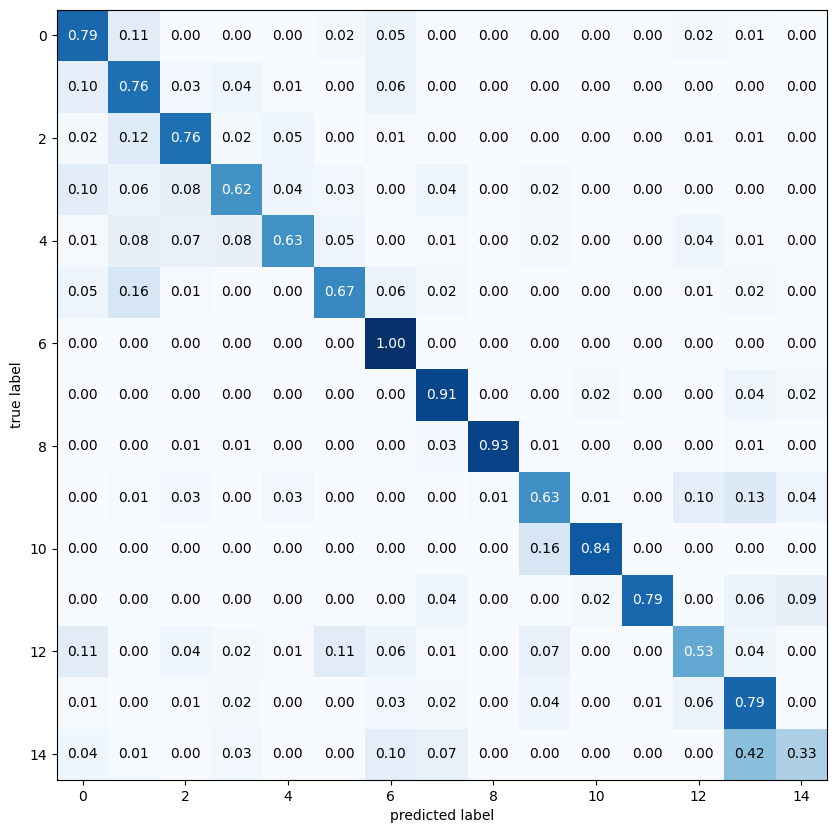

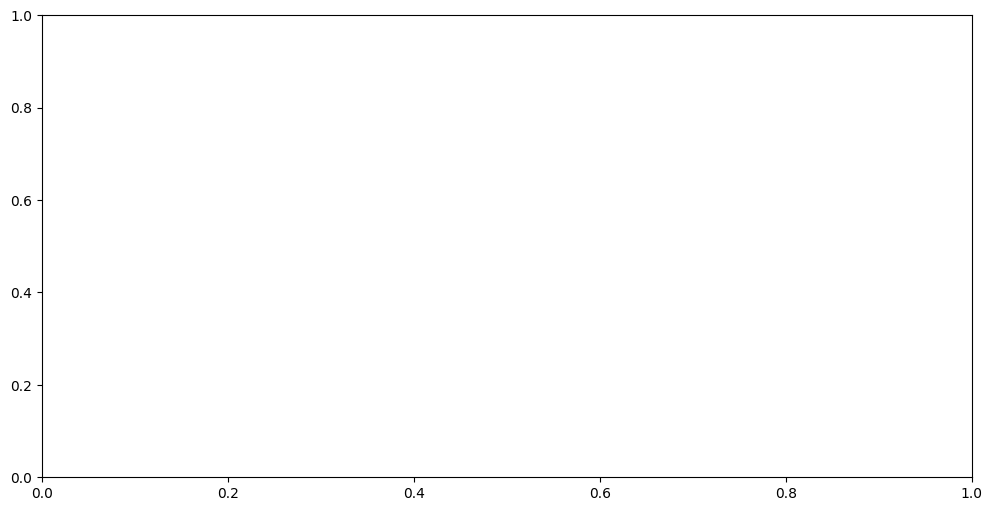

In [6]:

# Main
# ==============================================================================

globel_perd = []
globel_class = []

globel_perd1 = []
globel_class1 = []

# Create a workbook and add a worksheet.
workbook = xlsxwriter.Workbook(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\Trans_rslt.xlsx')
worksheet1 = workbook.add_worksheet('Subjects informations')

# Start from the first cell. Rows and columns are zero indexed.
row = 0

worksheet1.write(row, 0, 'Subject')
worksheet1.write(row, 1, 'Train_time')
worksheet1.write(row, 2, 'Test_time')
worksheet1.write(row, 3, 'Train_acc')
worksheet1.write(row, 4, 'Train_loss')
worksheet1.write(row, 5, 'Test_acc')
worksheet1.write(row, 6, 'Test_loss')
worksheet1.write(row, 7, 'MCC')

history = History()
for i in range(28, 29):
    loss_train, score_train, loss_test, score_test, y_pred, testy, train_time, test_time = run_my_experiment(i)

    globel_perd.append(y_pred)
    globel_class.append(testy)

    globel_perd1.extend(y_pred)
    globel_class1.extend(testy)

    mcc = matthews_corrcoef(testy, y_pred)
    mat = confusion_matrix(testy, y_pred)

    cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
    cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\S' + str(i) + 'trans_confusion_matrix.png')

    fig, axarr = plt.subplots(figsize=(12, 6), ncols=1)
    plot_renge = int(len(history.history['accuracy']) / i)
    global_renge = len(history.history['accuracy'])
    start_renge = global_renge - plot_renge
    axarr.plot(range(plot_renge), history.history['accuracy'][start_renge: global_renge], label='train score')
    axarr.plot(range(plot_renge), history.history['loss'][start_renge: global_renge], label='train loss')
    axarr.set_xlabel('Number of Epochs', fontsize=18)
    axarr.set_ylabel('Accuracy', fontsize=18)
    axarr.set_ylim([0, 2.5])
    plt.legend()
    plt.show()
    fig.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\S' + str(i) + 'trans_graphe.png')

    # Sheet informations
    worksheet1.write(i, 0, 'Sujet ' + str(i))
    worksheet1.write(i, 1, train_time)
    worksheet1.write(i, 2, test_time)
    worksheet1.write(i, 3, score_train)
    worksheet1.write(i, 4, loss_train)
    worksheet1.write(i, 5, score_test)
    worksheet1.write(i, 6, loss_test)
    worksheet1.write(i, 7, mcc)

workbook.close()

# Save prediction
new_data = {'pred_labels': globel_perd, 'class_labels': globel_class}
savemat(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\trans_global_predection.mat', new_data)

mat = confusion_matrix(globel_class1, globel_perd1)
cfm_plot, ax = plot_confusion_matrix(mat, figsize=(10, 10), show_normed=True, show_absolute=False)
cfm_plot.savefig(fr'D:\Transformer-Based-approach-for-hand-gesture-recognition-through-EMG-signals\DB2\results\results_droput\trans_global_confusion_matrix.png')


